# Trabajo Práctico 4 — Aprendizaje No-Supervisado
## Ejercicio 1: Inspección de los datos

---

**Dataset:**   
**Objetivo:** Explorar la naturaleza del dataset.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enable autoreload for automatic updates of imported modules
%load_ext autoreload
%autoreload 2

# Add src folder to path
import sys, os
ruta_src = os.path.abspath("src")
sys.path.append(ruta_src)

import utils, data_splitting, models, trainer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import torch

print(sys.executable)
print(torch.__version__)
print(torch.cuda.is_available())

c:\Users\pazbi\OneDrive\Escritorio\ml\ml_tp4\torch_env\Scripts\python.exe
2.12.0+cpu
False


In [7]:
np.random.seed(42)

In [8]:
# load data frame
df = pd.read_csv('data/raw/fashion_mnist_subset.csv')

In [9]:
# separate features and label
y = df["label"].values
X = df.drop("label", axis=1).values

In [10]:
# dataset summary 
summary_data, summary_labels = utils.dataset_summary(X, y)

In [11]:
display(summary_data)

,Métrica,Valor
0,Samples,"25,000"
1,Features,784 (28x28 px)
2,Classes,10
3,Pixel range,"[0.0, 1.0]"
4,Dtype,float64
5,NaN values,0
6,Balance,uniform


In [12]:
display(summary_labels)

,Class ID,Name,Count,Pct (%)
0,0,T-shirt/top,2500,10.0
1,1,Trouser,2500,10.0
2,2,Pullover,2500,10.0
3,3,Dress,2500,10.0
4,4,Coat,2500,10.0
5,5,Sandal,2500,10.0
6,6,Shirt,2500,10.0
7,7,Sneaker,2500,10.0
8,8,Bag,2500,10.0
9,9,Ankle boot,2500,10.0


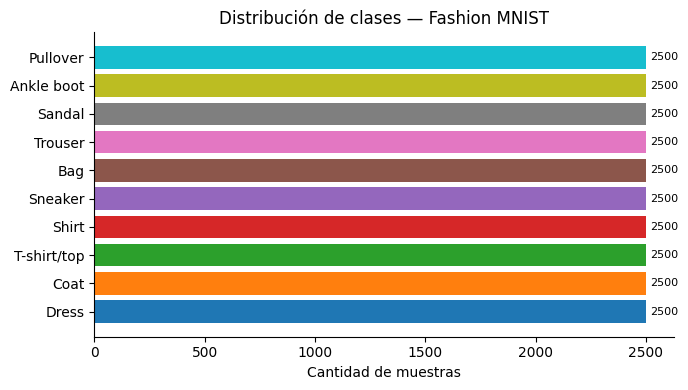

In [13]:
# show classes proportions
utils.show_proportions(df)

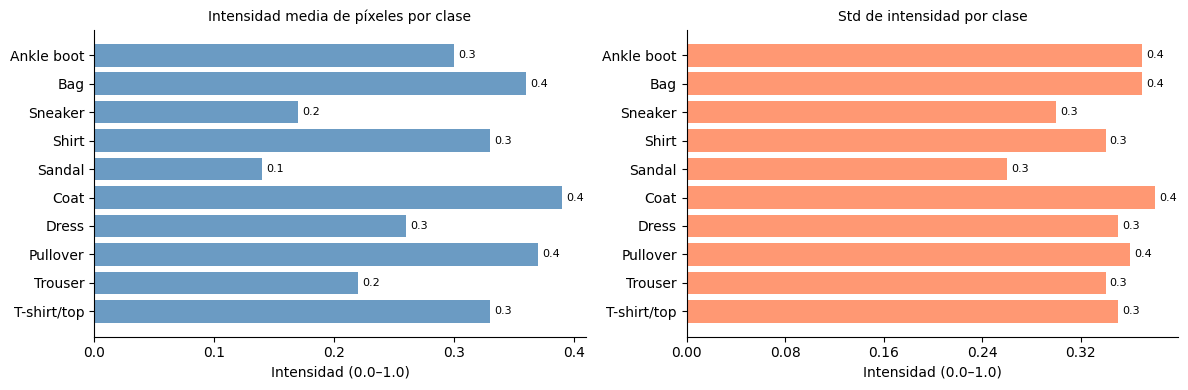

,class,mean_px,std_px
0,T-shirt/top,0.33,0.35
1,Trouser,0.22,0.34
2,Pullover,0.37,0.36
3,Dress,0.26,0.35
4,Coat,0.39,0.38
5,Sandal,0.14,0.26
6,Shirt,0.33,0.34
7,Sneaker,0.17,0.30
8,Bag,0.36,0.37
9,Ankle boot,0.30,0.37


In [14]:
pixel_stats = utils.analyze_pixels(X, y)
display(pixel_stats)

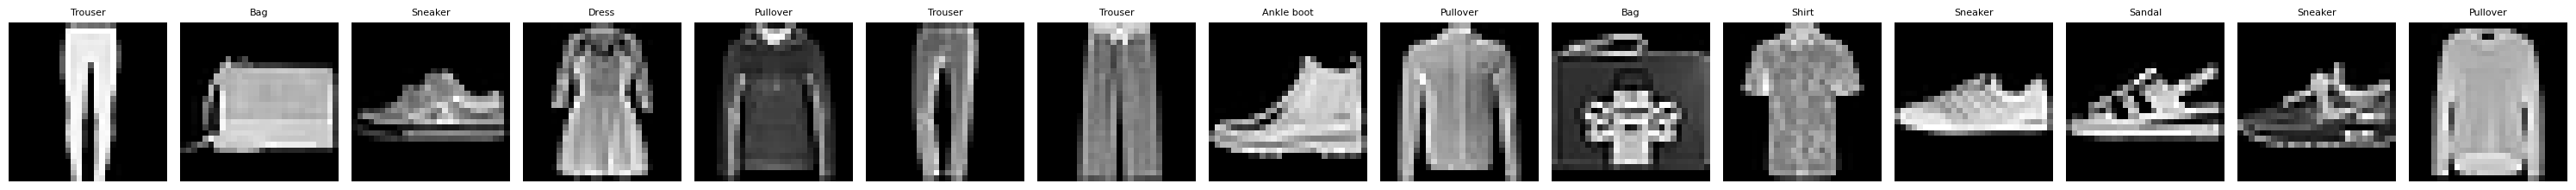

In [15]:
# show 15 random items
idx = utils.show_images(X, y, 15)

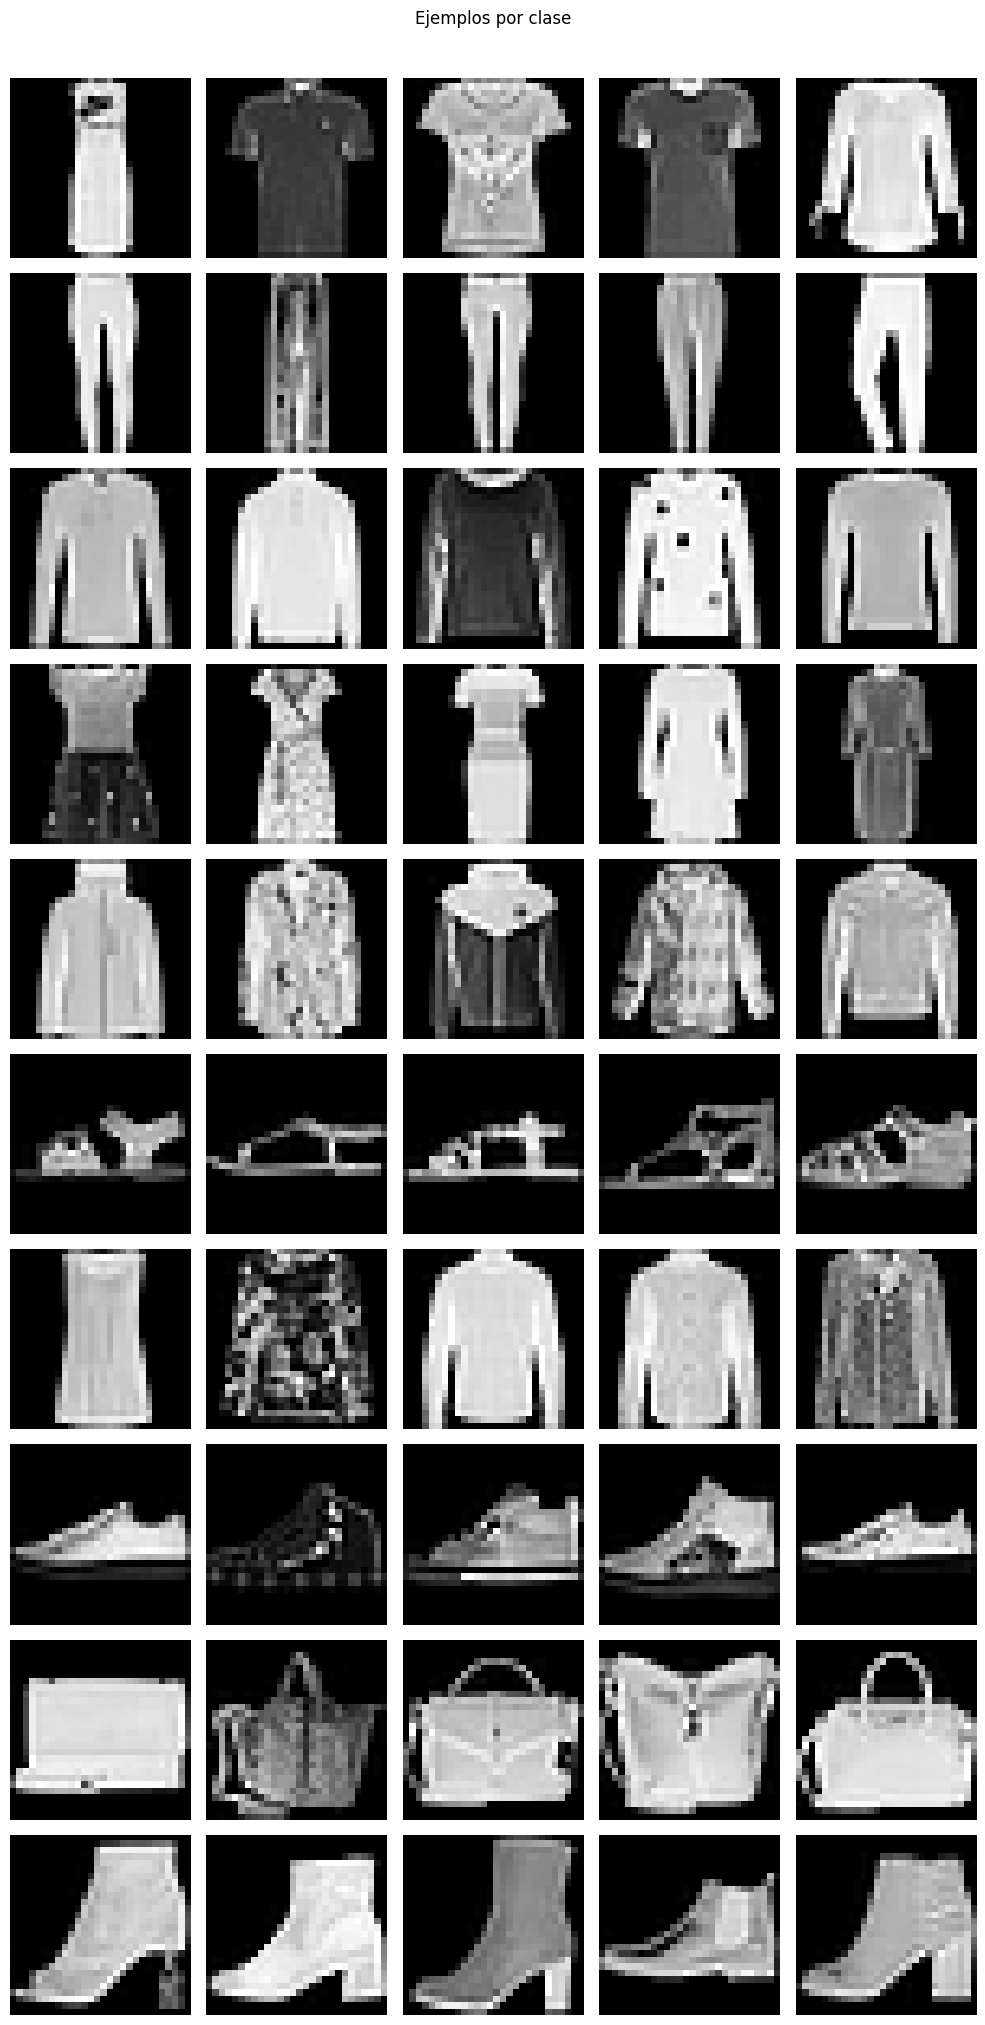

In [16]:
# show 5 items per class
utils.show_separate_classes(X, y, np.unique(y), 5)

In [17]:
# split data
train, test = data_splitting.random_stratified_split(df)

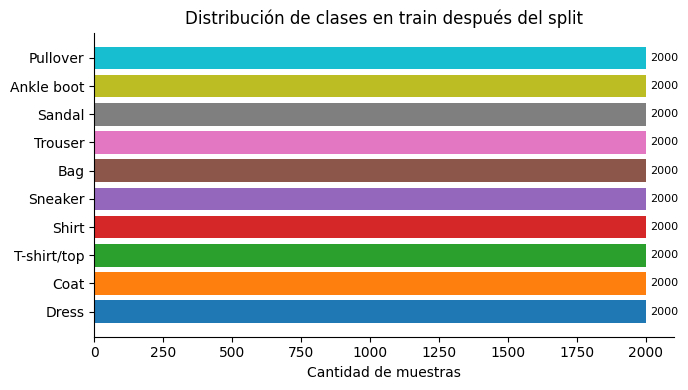

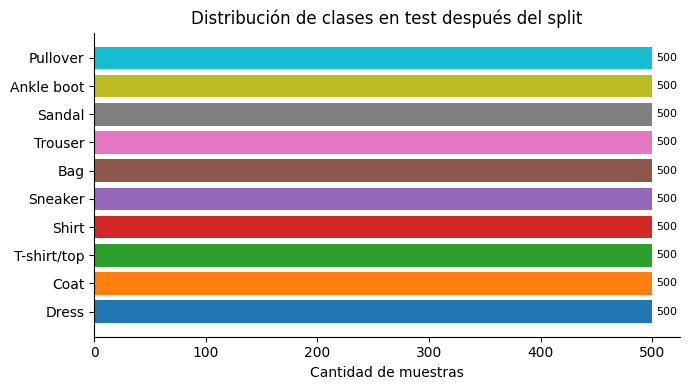

In [18]:
utils.show_proportions(train, title="Distribución de clases en train después del split")
utils.show_proportions(test, title="Distribución de clases en test después del split")

In [19]:
# separate features and label
y_train = train["label"].values
X_train = train.drop("label", axis=1)
y_test = test["label"].values
X_test = test.drop("label", axis=1)

## Ejercicio 2: Reducción de dimensionalidad

---

**Dataset:**   
**Objetivo:**

In [20]:
pca = models.PCA(k_components=784)

In [21]:
X_train_std = pca.fit_transform_scaler(X_train)
X_test_std = pca.transform_scaler(X_test)

_ = pca.fit_transform_pca(X_train_std)

Componentes para explicar 90% de varianza: 135


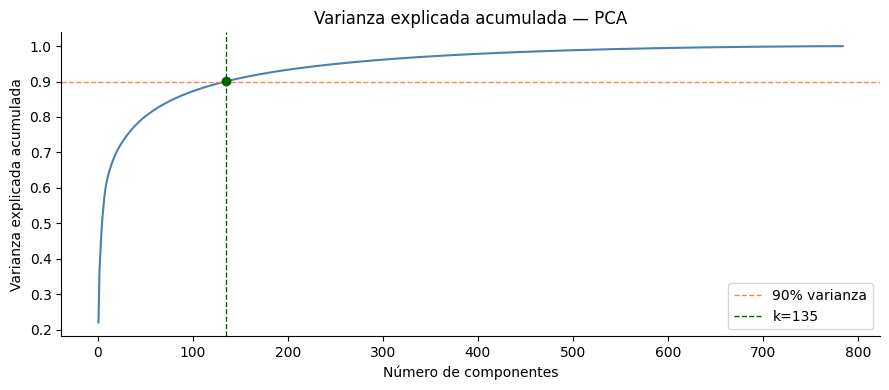

In [22]:
k_opt = utils.plot_explained_variance(pca)

In [23]:
pca_opt = models.PCA(k_components=k_opt)

In [24]:
X_train_std = pca.fit_transform_scaler(X_train)
X_test_std = pca.transform_scaler(X_test)

X_train_pca = pca.fit_transform_pca(X_train_std)
X_test_pca = pca.transform_pca(X_test_std)

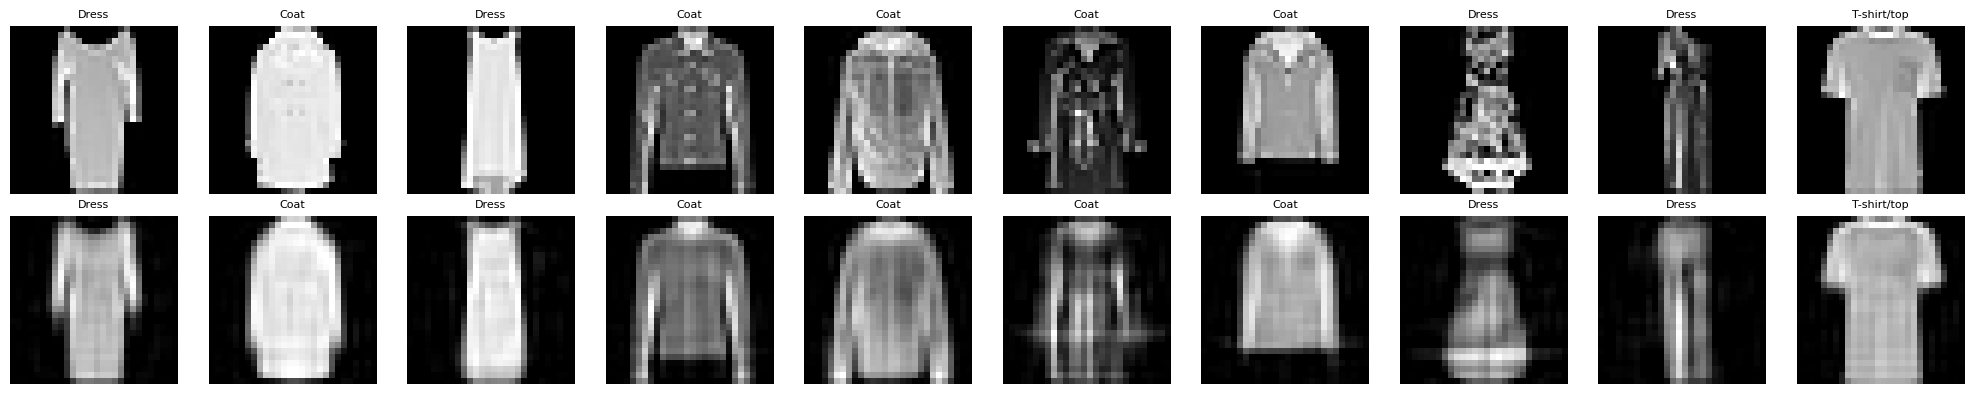

In [25]:
X_train_recon = utils.reconstruct(X_train_std, pca, k_opt)
indices = np.random.default_rng(42).choice(len(X_test), 10, replace=False)
utils.plot_reconstruction(X_train.values, X_train_recon, y_train ,indices)

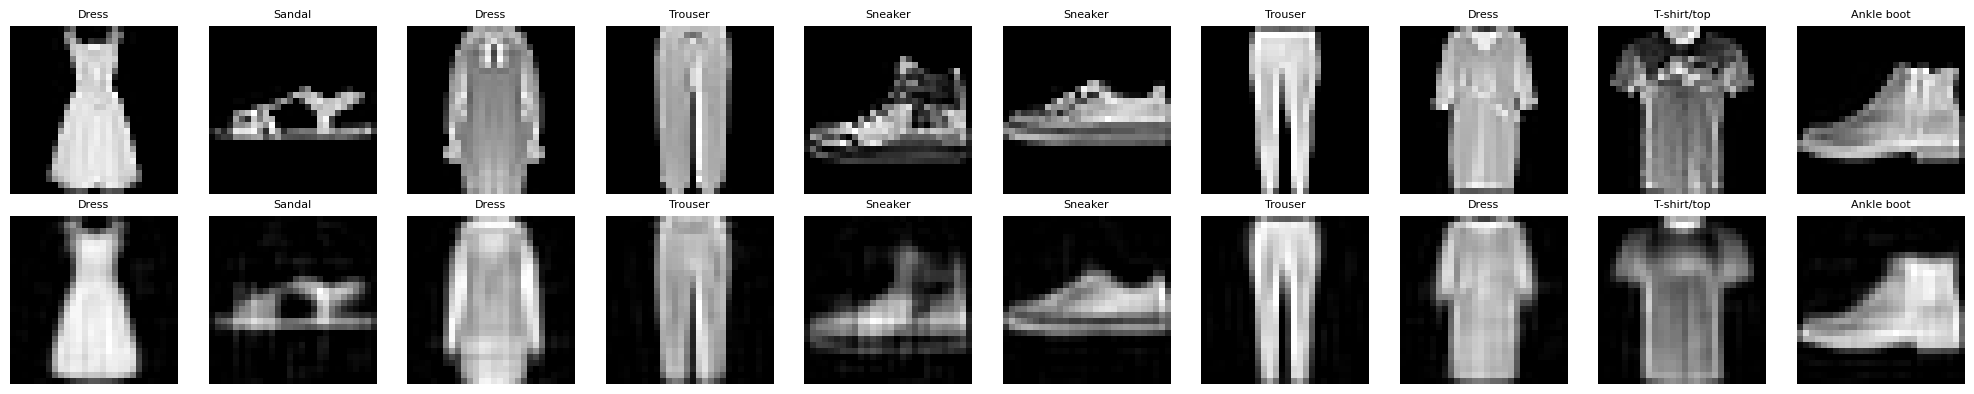

In [26]:
X_test_recon = utils.reconstruct(X_test_std, pca, k_opt)
indices = np.random.default_rng(42).choice(len(X_test), 10, replace=False)
utils.plot_reconstruction(X_test.values, X_test_recon, y_test, indices)

In [27]:
INPUT_DIM = 784
LATENT_DIM = k_opt
device = device = ("cuda" if torch.cuda.is_available() else "cpu")

Epoch  10/50  train=0.0170  test=0.0172
Epoch  20/50  train=0.0135  test=0.0135
Epoch  30/50  train=0.0115  test=0.0120
Epoch  40/50  train=0.0102  test=0.0109
Epoch  50/50  train=0.0094  test=0.0103


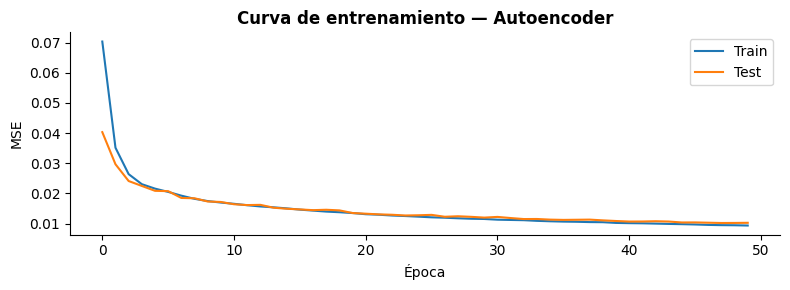

In [30]:
ae = models.AE(INPUT_DIM, LATENT_DIM).to(device)
train_losses, test_losses = trainer.train_AE(ae, X_train, X_test, device)
trainer.plot_loss(train_losses, test_losses)

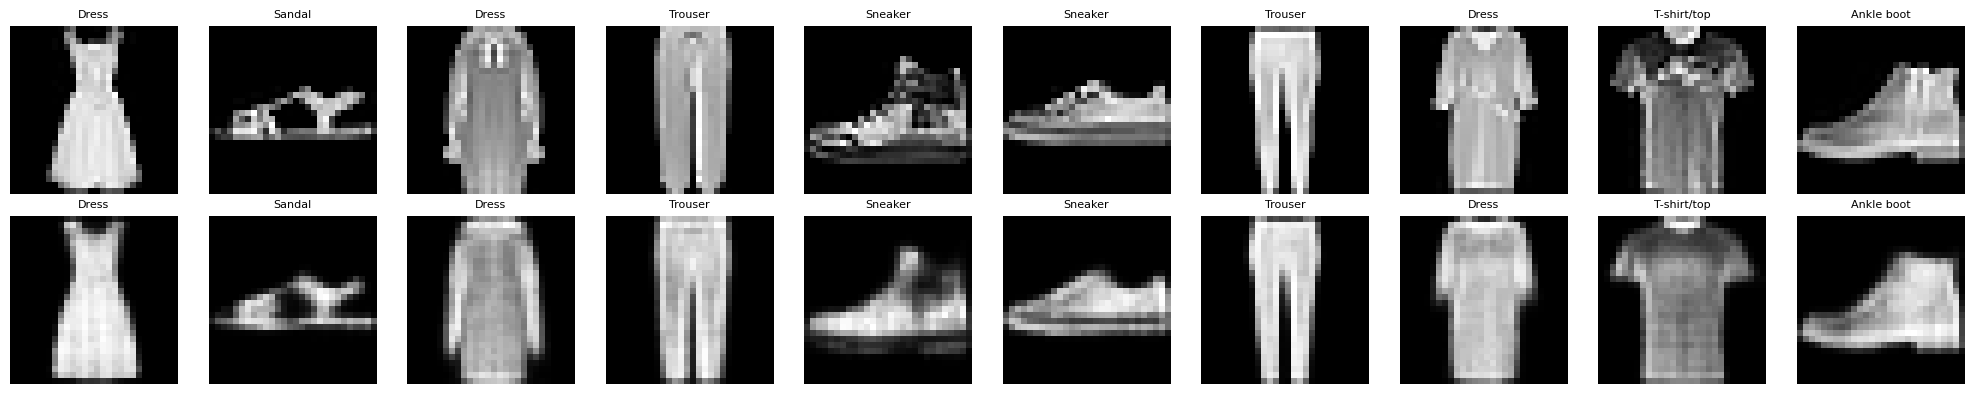

In [ ]:
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32).to(device)
X_test_recon_ae = ae(X_test_tensor).detach().cpu().numpy()
utils.plot_reconstruction(X_test, X_test_recon_ae, y_test, indices)   # mismos indices de 2b

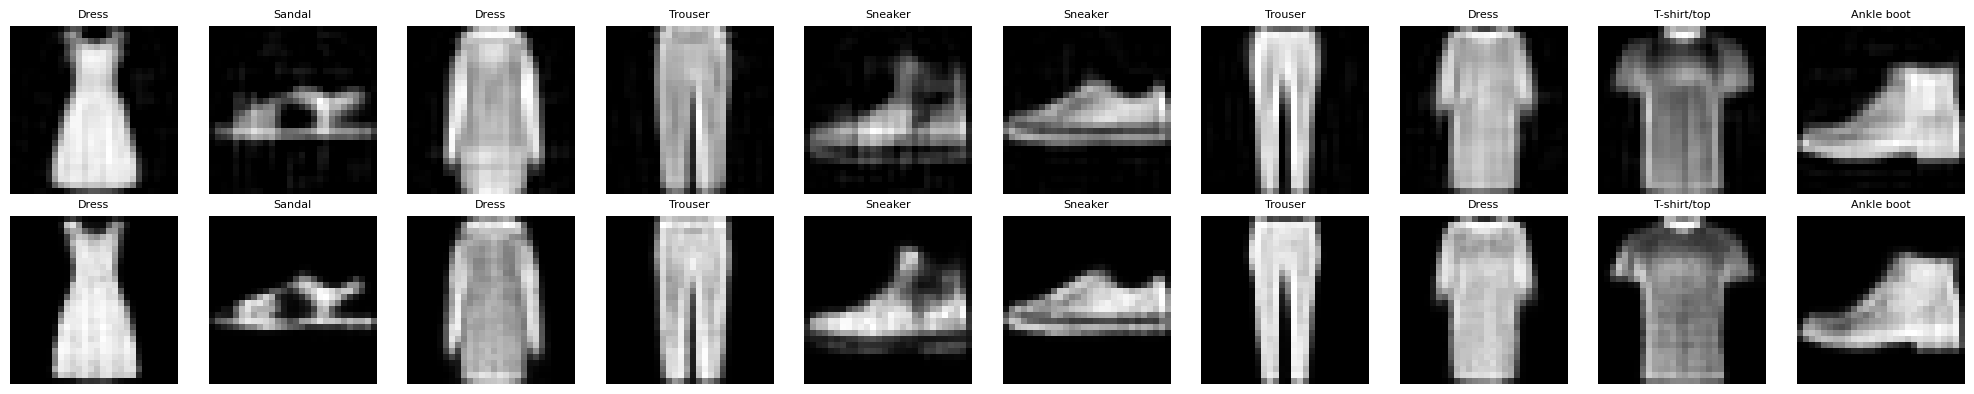

In [36]:
utils.plot_reconstruction(X_test_recon, X_test_recon_ae, y_test, indices)   # mismos indices de 2b

In [39]:
X_train_ae = trainer.encode_dataset(ae, X_train, device) #shape (n, K)
X_test_ae = trainer.encode_dataset(ae, X_test, device) #shape (m, K)